**질문 1.** sklearn의 datasets에서 load_sample_images() 함수의 리턴값을 받아 길이와 타입을 확인하고 이미지를 출력해보세요.

{'images': [array([[[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [250, 251, 255],
        [250, 251, 255],
        [250, 251, 255]],

       [[172, 199, 229],
        [173, 200, 230],
        [173, 200, 230],
        ...,
        [251, 252, 255],
        [251, 252, 255],
        [251, 252, 255]],

       [[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [252, 253, 255],
        [252, 253, 255],
        [252, 253, 255]],

       ...,

       [[ 88,  80,   7],
        [147, 138,  69],
        [122, 116,  38],
        ...,
        [ 39,  42,  33],
        [  8,  14,   2],
        [  6,  12,   0]],

       [[122, 112,  41],
        [129, 120,  53],
        [118, 112,  36],
        ...,
        [  9,  12,   3],
        [  9,  15,   3],
        [ 16,  24,   9]],

       [[116, 103,  35],
        [104,  93,  31],
        [108, 102,  28],
        ...,
        [ 43,  49,  39],
        [ 13,  21,   6],
        [ 15

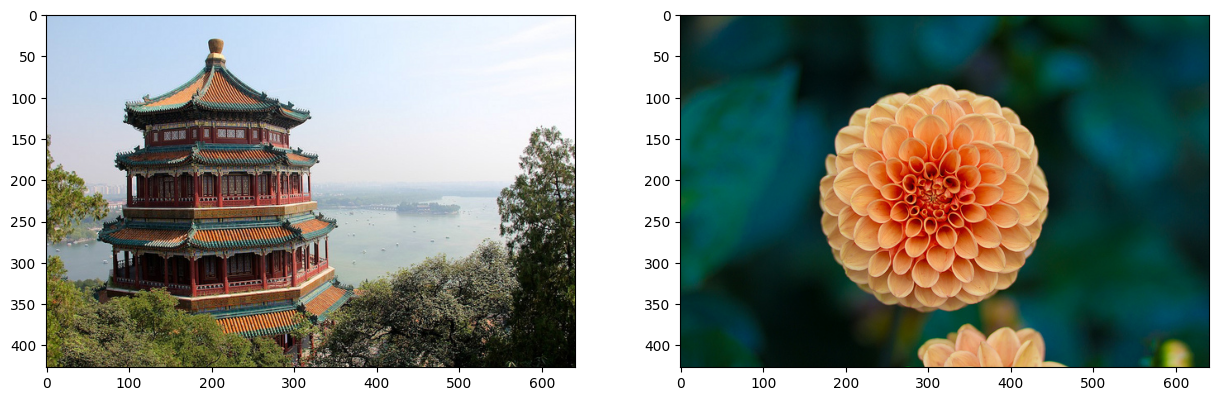

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt

dataset = datasets.load_sample_images()
#데이터 셋 확인
print(dataset)

#길이와 타입 확인
print(f"length : {len(dataset.images)}, type : {type(dataset.images)}")

#이미지 출력
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
for ax, image in zip(axes, dataset['images']):
    ax.imshow(image)

**질문 2.** 위 이미지 데이터에서 x,y축의 표시를 제거하고 'flower' 이미지만 출력해보세요

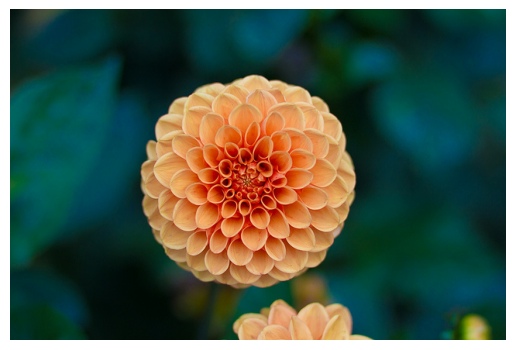

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt

dataset = datasets.load_sample_images()

flower_image = dataset.images[1]

# Plot the image using matplotlib
plt.imshow(flower_image)
plt.axis('off')
plt.show()

**질문 3.**	스크래핑을 활용해서 '한식' 이미지를 10개 출력해보세요.

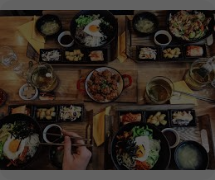

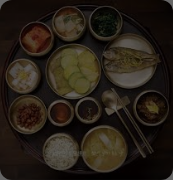

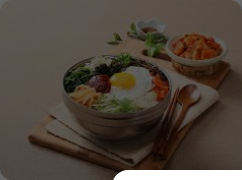

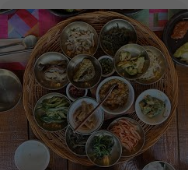

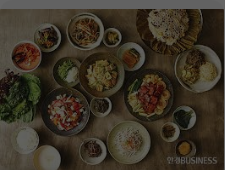

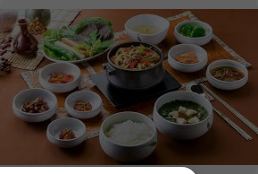

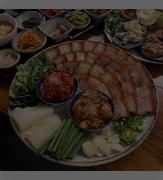

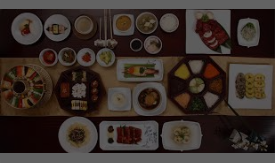

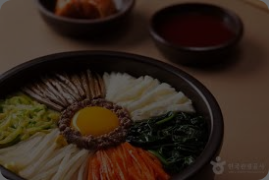

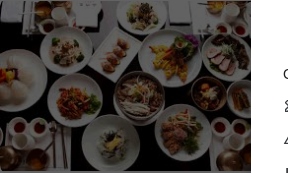

출력 완료: 10개


In [13]:
# =========================
# 0) 설치
# =========================
!pip -q install -U selenium webdriver-manager

# =========================
# 1) import
# =========================
import time
from urllib.parse import urlencode

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType

from IPython.display import Image, display

# =========================
# 2) 드라이버 실행 (Colab: Chromium)
# =========================
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")

service = Service(ChromeDriverManager(chrome_type=ChromeType.CHROMIUM).install())
driver = webdriver.Chrome(service=service, options=options)

# =========================
# 3) "한식" 이미지 10개 출력 함수 (URL이 아니라 썸네일 캡쳐)
# =========================
def show_korean_food_images(count=10, keyword="한식", scroll_times=8):
    base = "https://www.google.com/search"
    params = {"q": keyword, "udm": "2", "hl": "ko"}
    url = f"{base}?{urlencode(params)}"

    driver.get(url)
    time.sleep(2)

    # 스크롤로 썸네일 더 로드
    for _ in range(scroll_times):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(0.8)

    # 구글 이미지 썸네일에서 자주 쓰이는 클래스들 (환경 따라 다름)
    candidates = []
    selectors = [
        "img.Q4LuWd",
        "img.YQ4gaf",
        "img.rg_i"
    ]
    for sel in selectors:
        candidates.extend(driver.find_elements(By.CSS_SELECTOR, sel))

    # 중복 제거(같은 요소가 여러 셀렉터에 걸릴 수 있음)
    seen = set()
    thumbs = []
    for el in candidates:
        key = el.id
        if key in seen:
            continue
        seen.add(key)

        # 너무 작은 UI 아이콘(구글 로고 등) 거르기
        size = el.size
        if size.get("width", 0) < 80 or size.get("height", 0) < 80:
            continue

        thumbs.append(el)

    # 실제 출력: 요소 자체를 PNG로 캡쳐해서 표시
    printed = 0
    for el in thumbs:
        if printed >= count:
            break
        try:
            png = el.screenshot_as_png
            display(Image(data=png))
            printed += 1
        except:
            pass

    print(f"출력 완료: {printed}개")

# =========================
# 4) 실행
# =========================
show_korean_food_images(10, "한식")

driver.quit()


**질문 4.**	이미지 개수를 인자로 받아서 해당하는 개수만큼 이미지가 출력되도록 모듈을 작성해 보세요.

In [20]:
!pip -q install -U selenium webdriver-manager

import time
from urllib.parse import urlencode
from IPython.display import Image, display

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType


def showImg(count):
    # 1) 드라이버 생성 (세션 꼬임 방지: 함수 안에서 생성)
    options = webdriver.ChromeOptions()
    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--lang=ko-KR")

    service = Service(ChromeDriverManager(chrome_type=ChromeType.CHROMIUM).install())
    driver = webdriver.Chrome(service=service, options=options)

    try:
        # 2) 검색
        text = "한식"
        base = "https://www.google.com/search"
        params = {"q": text, "udm": "2", "hl": "ko"}
        url = f"{base}?{urlencode(params)}"
        driver.get(url)

        time.sleep(2)

        # 3) 스크롤
        for _ in range(8):
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(0.8)

        # 4) 이미지 URL 수집
        imgs = driver.find_elements(By.CSS_SELECTOR, "img")
        urls = []
        for img in imgs:
            src = img.get_attribute("src") or img.get_attribute("data-src")
            if src and src.startswith("http"):
                urls.append(src)

        # 중복 제거
        urls = list(dict.fromkeys(urls))

        # 5) count 개 출력
        printed = 0
        for u in urls:
            if printed >= count:
                break
            display(Image(url=u))
            printed += 1

        print(f"출력 완료: {printed}개")

    finally:
        driver.quit()


# 실행
showImg(3)


출력 완료: 2개


**질문 5.**	4번 문제에 이어서, 특정 키워드를 인자로 받으면 해당하는 이미지를 출력하게 작성해보세요.

In [22]:
!pip -q install -U selenium webdriver-manager

import time
from urllib.parse import urlencode
from IPython.display import Image, display

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from webdriver_manager.core.os_manager import ChromeType


def showImg(count, keyword):
    # 1) 드라이버 생성 (함수 안에서 생성해야 세션 꼬임 없음)
    options = webdriver.ChromeOptions()
    options.add_argument("--headless=new")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--window-size=1920,1080")
    options.add_argument("--lang=ko-KR")

    service = Service(ChromeDriverManager(chrome_type=ChromeType.CHROMIUM).install())
    driver = webdriver.Chrome(service=service, options=options)

    try:
        # 2) 검색 페이지 접속
        base = "https://www.google.com/search"
        params = {"q": keyword, "udm": "2", "hl": "ko"}
        url = f"{base}?{urlencode(params)}"
        driver.get(url)

        time.sleep(2)

        # 3) 스크롤
        for _ in range(8):
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(0.8)

        # 4) 이미지 URL 수집
        imgs = driver.find_elements(By.CSS_SELECTOR, "img")
        urls = []
        for img in imgs:
            src = img.get_attribute("src") or img.get_attribute("data-src")
            if src and src.startswith("http"):
                urls.append(src)

        # 중복 제거
        urls = list(dict.fromkeys(urls))

        # 5) count 개 출력
        printed = 0
        for u in urls:
            if printed >= count:
                break
            display(Image(url=u))
            printed += 1

        print(f"출력 완료: {printed}개")

    finally:
        driver.quit()


print("원하는 이미지 이름을 입력해주세요.")
word = input()
showImg(3, word)


원하는 이미지 이름을 입력해주세요.
사자


출력 완료: 2개
